# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [2]:
import argparse

parser = argparse.ArgumentParser(
    description="Many-body vs Random-Phase neutrino oscillation simulation"
)

parser.add_argument(
    "--Ne",
    type=int,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    help="Number of initially x-flavor neutrinos",
)

args, _ = parser.parse_known_args()

if args.Ne is None:
    Ne = int(input("Enter the number of electron-flavor neutrinos (Ne): "))
else:
    Ne = args.Ne

if args.Nx is None:
    Nx = int(input("Enter the number of x-flavor neutrinos (Nx): "))
else:
    Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  2
Enter the number of x-flavor neutrinos (Nx):  8


In [3]:
# =============================
# CELL 1: Imports and parameters
# =============================

# -----------------------------
# Particle numbers
# -----------------------------


# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = 1

# -----------------------------
# Evolution choices
# -----------------------------
# Keep these False to match the later cells of the old e1_x15 notebook:
# self-interaction only, with no vacuum and no matter term.
use_vacuum = False
use_matter = False

# -----------------------------
# Time / Trotter / sampling parameters
# -----------------------------
dt = 0.5
T_max = 10 #200.0
sample_every = 2

n_steps_max = int(round(T_max / dt))
times = np.arange(0, n_steps_max + 1, sample_every) * dt

# -----------------------------
# Qiskit simulation parameters
# -----------------------------
shots = 4096
seed_simulator = 12345
backend = AerSimulator(seed_simulator=seed_simulator)

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(f"Number of sampled times = {len(times)}, T_max = {T_max}, dt = {dt}")
print(f"Evolution mode: self-interaction only = {not use_vacuum and not use_matter}")

Using Ne = 2, Nx = 8, total N = 10
omega1 = 0.25
mu = omega1 * N = 1
Number of sampled times = 11, T_max = 10, dt = 0.5
Evolution mode: self-interaction only = True


In [4]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================



#J = interaction_matrix(N, dm2, E)
J=1
#print("J shape =", J.shape)
#print("J min/max =", J.min(), J.max())

In [5]:
# ============================================================
# COMPLETE THIRD-ORDER ZASSENHAUS BLOCK FOR ARBITRARY QUBITS
#
# X = -i H_ab dt
# Y = -i H_bc dt
#
# exp(X+Y) ~= exp(Z) exp(X)
#
# Z = Y
#   + 1/2 [X,Y]
#   + 1/6 [X,[X,Y]]
#   + 1/12 [Y,[X,Y]]
#
# This routine allows (a,b,c) to be non-consecutive qubits.
# That is needed for the physical arrangement
#
#       q0, q1 = nu_e
#       q2,... = nu_x
#
# For an x-qubit k we use the block
#
#       H_{e0,k} + H_{k,e1}
#
# i.e. (a,b,c) = (e0,k,e1).
# ============================================================

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate


def _two_local_operator(n, qa, qb, pauli, coefficient):
    chars = ["I"] * n
    chars[qa] = pauli
    chars[qb] = pauli
    return SparsePauliOp.from_list([
        ("".join(reversed(chars)), complex(coefficient))
    ])


def _heisenberg_pair_operator(n, qa, qb, J):
    """J (X_a X_b + Y_a Y_b + Z_a Z_b)."""
    return (
        _two_local_operator(n, qa, qb, "X", J)
        + _two_local_operator(n, qa, qb, "Y", J)
        + _two_local_operator(n, qa, qb, "Z", J)
    )


def _three_local_pauli_operator(n, qa, qb, qc, p_a, p_b, p_c, coefficient):
    """Coefficient * P_a(qa) P_b(qb) P_c(qc), for arbitrary qubits."""
    chars = ["I"] * n
    chars[qa] = p_a
    chars[qb] = p_b
    chars[qc] = p_c
    return SparsePauliOp.from_list([
        ("".join(reversed(chars)), complex(coefficient))
    ])


def add_zassenhaus_123_evolution(qc, n, J, dt, qa, qb, qc_qubit, order=3):
    """
    Zassenhaus correction for two Heisenberg pair interactions

        H1 = H_{a b}
        H2 = H_{b c}

    with

        X = -i H1 dt
        Y = -i H2 dt.

    Through complete third order,

        Z = Y
          + 1/2 [X,Y]
          + 1/6 [X,[X,Y]]
          + 1/12 [Y,[X,Y]]

    and

        exp(X+Y) ~= exp(Z) exp(X).

    qa, qb, qc_qubit may be non-consecutive physical qubits.
    """

    if order not in (1, 2, 3):
        raise ValueError("order must be 1, 2, or 3")

    if n != qc.num_qubits:
        raise ValueError(
            f"Qubit-count mismatch: n={n}, qc.num_qubits={qc.num_qubits}"
        )

    if len({qa, qb, qc_qubit}) != 3:
        raise ValueError("qa, qb, qc_qubit must be three distinct qubits")

    for q in (qa, qb, qc_qubit):
        if q < 0 or q >= n:
            raise ValueError(f"Invalid qubit {q} for n={n}")

    # H1 = J P_ab, H2 = J P_bc
    H1 = _heisenberg_pair_operator(n, qa, qb, J)
    H2 = _heisenberg_pair_operator(n, qb, qc_qubit, J)

    H_Z = H2

    # ------------------------------------------------------------
    # 1/2 [X,Y]
    #
    # Hcorr2 =
    # J^2 dt [
    #   - X_a Y_b Z_c + X_a Z_b Y_c
    #   + Y_a X_b Z_c - Y_a Z_b X_c
    #   - Z_a X_b Y_c + Z_a Y_b X_c
    # ]
    # ------------------------------------------------------------
    if order >= 2:
        c2 = J**2 * dt

        terms = [
            (+c2, "XYZ"),
            (-c2, "XZY"),
            (-c2, "YXZ"),
            (+c2, "YZX"),
            (+c2, "ZXY"),
            (-c2, "ZYX"),
        ]

        Hcorr2 = SparsePauliOp.from_list([
            (
                "".join(reversed([
                    p[0] if q == qa else
                    p[1] if q == qb else
                    p[2] if q == qc_qubit else "I"
                    for q in range(n)
                ])),
                complex(coeff)
            )
            for coeff, p in terms
        ])

        H_Z = H_Z + Hcorr2

    # ------------------------------------------------------------
    # 1/6 [X,[X,Y]]
    #
    # Hcorr_xxy = (4/3) J^3 dt^2 (P_ac - P_bc)
    # ------------------------------------------------------------
    if order >= 3:
        coeff_xxy = (4.0 / 3.0) * J**3 * dt**2

        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qc_qubit, +coeff_xxy
        )
        H_Z = H_Z + _heisenberg_pair_operator(
            n, qb, qc_qubit, -coeff_xxy
        )

        # --------------------------------------------------------
        # 1/12 [Y,[X,Y]]
        #
        # Hcorr_yxy = (2/3) J^3 dt^2 (P_ab - P_ac)
        # --------------------------------------------------------
        coeff_yxy = (2.0 / 3.0) * J**3 * dt**2

        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qb, -coeff_yxy
        )
        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qc_qubit, +coeff_yxy
        )

    # exp(Z) exp(X)
    qc.append(
        PauliEvolutionGate(H_Z, time=dt),
        qc.qubits
    )
    qc.append(
        PauliEvolutionGate(H1, time=dt),
        qc.qubits
    )

    return qc


In [6]:

# ============================================================
# Zassenhaus control
# ============================================================
#
# 1 = ordinary first-order pair splitting
# 2 = include 1/2 [X,Y]
# 3 = include 1/2 [X,Y] + 1/6 [X,[X,Y]]
#
# The main add_interaction_evolution(, zassenhaus_order=3) calls above are set to 3.
# Change those calls to zassenhaus_order=1 or 2 for comparison.
#
ZASSENHAUS_ORDER = 3


In [7]:
# ============================================================
# Interaction evolution with Zassenhaus correction
#
# Qubit arrangement is determined ONLY by Ne and Nx:
#
#   q = 0,...,Ne-1       : nu_e
#   q = Ne,...,Ne+Nx-1   : nu_x
#
# The routine therefore works for arbitrary Ne and Nx.
# ============================================================

def add_interaction_evolution(
    qc, n, J, N, dt, zassenhaus_order=3, Ne=None, Nx=None
):
    """
    Apply n Trotter steps of the interaction evolution.

    Parameters
    ----------
    qc : QuantumCircuit
    n : int
        Number of Trotter steps.
    J : float
        Pair coupling.
    N : int
        Total number of qubits = Ne + Nx.
    dt : float
        Trotter time step.
    zassenhaus_order : int
        1, 2, or 3.
    Ne, Nx : int
        Number of initially electron-flavor and x-flavor qubits.

    Qubit ordering:
        [nu_e ... nu_e | nu_x ... nu_x]

    For each nu_x qubit, the interactions with the nu_e group
    are collected into Zassenhaus blocks. Remaining pair
    interactions are handled by ordinary pair evolution.
    """

    if zassenhaus_order not in (1, 2, 3):
        raise ValueError("zassenhaus_order must be 1, 2, or 3")

    if qc.num_qubits != N:
        raise ValueError(
            f"Qubit-count mismatch: N={N}, but qc has "
            f"{qc.num_qubits} qubits."
        )

    if Ne is None or Nx is None:
        raise ValueError("Ne and Nx must be supplied.")

    if Ne < 0 or Nx < 0 or Ne + Nx != N:
        raise ValueError(
            f"Require Ne >= 0, Nx >= 0, and Ne + Nx = N; "
            f"got Ne={Ne}, Nx={Nx}, N={N}."
        )

    # ------------------------------------------------------------
    # One Trotter step
    # ------------------------------------------------------------
    for _ in range(n):

        used_pairs = set()

        # --------------------------------------------------------
        # Zassenhaus correction for e-x interactions.
        #
        # For each x qubit, group its interactions with the
        # electron-flavor qubits in consecutive two-term blocks.
        #
        # For example, for Ne=4 and one x qubit x:
        #
        #   (e0,x) + (e1,x)
        #   (e2,x) + (e3,x)
        #
        # If Ne is odd, the final e-x pair is applied normally.
        # --------------------------------------------------------
        for xq in range(Ne, N):

            eq = 0

            while eq + 1 < Ne:
                e1 = eq
                e2 = eq + 1

                add_zassenhaus_pair_evolution(
                    qc,
                    n=N,
                    J=J,
                    dt=dt,
                    qa=e1,
                    qb=xq,
                    qcq=e2,
                    order=zassenhaus_order,
                )

                used_pairs.add(tuple(sorted((e1, xq))))
                used_pairs.add(tuple(sorted((e2, xq))))

                eq += 2

            # Odd Ne: one e-x pair remains.
            if eq < Ne:
                H_ex = _heisenberg_pair_operator(
                    N, eq, xq, J
                )
                qc.append(
                    PauliEvolutionGate(H_ex, time=dt),
                    qc.qubits,
                )
                used_pairs.add(tuple(sorted((eq, xq))))

        # --------------------------------------------------------
        # All remaining pair interactions.
        #
        # This keeps the full pair Hamiltonian when Ne/Nx are
        # changed. Pairs already included in a Zassenhaus block
        # are not repeated.
        # --------------------------------------------------------
        for qa in range(N):
            for qb in range(qa + 1, N):

                pair = (qa, qb)

                if pair in used_pairs:
                    continue

                H_pair = _heisenberg_pair_operator(
                    N, qa, qb, J
                )

                qc.append(
                    PauliEvolutionGate(H_pair, time=dt),
                    qc.qubits,
                )

    return qc


def add_zassenhaus_pair_evolution(
    qc, n, J, dt, qa, qb, qcq, order=3
):
    """
    Zassenhaus block for two Heisenberg interactions sharing
    the qubit qb:

        H_ab = J P_ab
        H_bc = J P_bc

    with

        X = -i H_ab dt
        Y = -i H_bc dt

    and

        Z = Y
          + 1/2 [X,Y]
          + 1/6 [X,[X,Y]]
          + 1/12 [Y,[X,Y]].

    The qubit labels qa, qb, qcq can be arbitrary; they do not
    need to be consecutive.
    """

    if order not in (1, 2, 3):
        raise ValueError("order must be 1, 2, or 3")

    if len({qa, qb, qcq}) != 3:
        raise ValueError("qa, qb, qcq must be three distinct qubits.")

    H_ab = _heisenberg_pair_operator(n, qa, qb, J)
    H_bc = _heisenberg_pair_operator(n, qb, qcq, J)

    H_Z = H_bc

    # ------------------------------------------------------------
    # 1/2 [X,Y]
    # ------------------------------------------------------------
    if order >= 2:
        # The signs depend on the ordering of qa-qb-qcq.
        #
        # For H_ab followed by H_bc:
        #
        # Hcorr2 =
        # J^2 dt [
        #   - X_a Y_b Z_c
        #   + X_a Z_b Y_c
        #   + Y_a X_b Z_c
        #   - Y_a Z_b X_c
        #   - Z_a X_b Y_c
        #   + Z_a Y_b X_c
        # ]
        #
        # Build these directly on arbitrary qubits.
        terms = [
            (-J**2 * dt, ("X", "Y", "Z")),
            (+J**2 * dt, ("X", "Z", "Y")),
            (+J**2 * dt, ("Y", "X", "Z")),
            (-J**2 * dt, ("Y", "Z", "X")),
            (-J**2 * dt, ("Z", "X", "Y")),
            (+J**2 * dt, ("Z", "Y", "X")),
        ]

        Hcorr2 = []
        for coeff, ps in terms:
            chars = ["I"] * n
            chars[qa] = ps[0]
            chars[qb] = ps[1]
            chars[qcq] = ps[2]
            Hcorr2.append(("".join(reversed(chars)), complex(coeff)))

        H_Z = H_Z + SparsePauliOp.from_list(Hcorr2)

    # ------------------------------------------------------------
    # Complete third order
    #
    # 1/6 [X,[X,Y]]
    #   -> (4/3) J^3 dt^2 (P_ac - P_bc)
    #
    # 1/12 [Y,[X,Y]]
    #   -> (2/3) J^3 dt^2 (P_ab - P_ac)
    # ------------------------------------------------------------
    if order >= 3:

        coeff_xxy = (4.0 / 3.0) * J**3 * dt**2

        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qcq, +coeff_xxy
        )
        H_Z = H_Z + _heisenberg_pair_operator(
            n, qb, qcq, -coeff_xxy
        )

        coeff_yxy = (2.0 / 3.0) * J**3 * dt**2

        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qb, +coeff_yxy
        )
        H_Z = H_Z + _heisenberg_pair_operator(
            n, qa, qcq, -coeff_yxy
        )

    # exp(Z) exp(X)
    qc.append(
        PauliEvolutionGate(H_Z, time=dt),
        qc.qubits
    )

    qc.append(
        PauliEvolutionGate(H_ab, time=dt),
        qc.qubits
    )

    return qc


In [8]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Parameters
    ----------
    t_table : array
        Sampled times.
    theta : float
        Vacuum mixing angle.
    omega : array
        Vacuum frequencies for all modes.
    lam : float
        Matter strength.
    J : array
        Coupling matrix.
    initial_flavors : array
        Entries may be:
            'e'  : |nu_e>
            'x'  : |nu_mu>
            'mu' : |nu_mu>
            'a'  : cos(alpha)|nu_e> + sin(alpha)|nu_mu>
    alpha : float
        Superposition angle for every mode labeled 'a'.
    """
    n_modes = omega.size

    u = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T
    l = np.diag([1, 0])

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    B = np.real(np.array([np.trace(b @ sigma_1),
                          np.trace(b @ sigma_2),
                          np.trace(b @ sigma_3)]))
    L = np.real(np.array([np.trace(l @ sigma_1),
                          np.trace(l @ sigma_2),
                          np.trace(l @ sigma_3)]))

    ini_state = np.where(omega > 0, Ee[:, None], Emu[:, None])

    if initial_flavors is not None:
        initial_flavors = np.asarray(initial_flavors)

        for f in initial_flavors:
            if f not in ["e", "x", "mu", "a"]:
                raise ValueError(f"Unknown flavor label: {f}")
            if f == "a" and alpha is None:
                raise ValueError("Flavor label 'a' requires alpha.")

        ini_state[:, initial_flavors == "e"] = Ee[:, None]
        ini_state[:, initial_flavors == "x"] = Emu[:, None]
        ini_state[:, initial_flavors == "mu"] = Emu[:, None]
        ini_state[:, initial_flavors == "a"] = np.array(
            [np.sin(2.0 * alpha), 0.0, np.cos(2.0 * alpha)]
        )[:, None]

    def rhs(t, P_flat):
        """
        dP_k/dt = H_k x P_k,
        H_k = omega_k B + lambda L + sum_j J_kj P_j.
        """
        res = np.zeros(3 * n_modes)
        PP = np.reshape(P_flat, (n_modes, 3)).T
        
        for k in range(n_modes):
            H_k = omega[k] * B + lam * L + J * np.sum(PP, axis=1)
            res[3*k:3*k+3] = np.cross(H_k, PP[:, k])

        return res
    
    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
    )

In [9]:
# =====================================================
# CELL 5: Many-body Qiskit solver for Ne + Nx(alpha)
# =====================================================

def prepare_initial_circuit(Ne, Nx, alpha):
    """
    Prepare the initial many-body state:

        q=0,...,Ne-1: |nu_e> = |0>
        q=Ne,...,N-1: |nu_x(alpha)> = cos(alpha)|0> + sin(alpha)|1>

    For the present calculation Ne=2, so q=0,1 are nu_e and
    q=2,...,N-1 are nu_x.

    RY(2 alpha)|0> = cos(alpha)|0> + sin(alpha)|1>.

    For alpha = pi/2, the Nx group is exactly |1>, reproducing
    the old 1 nu_e + 15 nu_mu setup when Ne=1, Nx=15.
    """
    N = Ne + Nx
    qc0 = QuantumCircuit(N, N)

    # First Ne qubits are |nu_e> = |0>, so no gate is needed.
    for q in range(Ne, N):
        qc0.ry(2.0 * alpha, q)

    return qc0


def run_many_body_qiskit(alpha, Ne, Nx, J, times, dt, shots, backend,
                         use_vacuum=False, bx=0.0, by=0.0, bz=0.0,
                         verbose=True):
    """
    Run the many-body Qiskit simulation for a given alpha.

    Output
    ------
    P_bit1[q, k] :
        Probability that qubit q is measured as |1> at time times[k].

    For the first Ne qubits, which start as |nu_e>=|0>,
        P_bit1 = P(nu_e -> nu_mu).

    The plotted observable is the Ne-average:
        <P(nu_e -> nu_mu)> over the initially electron-flavor group.
    """
    N = Ne + Nx
    qc0 = prepare_initial_circuit(Ne, Nx, alpha)

    P_bit1 = [[] for _ in range(N)]

    for t in times:
        n = int(round(t / dt))
        qc = qc0.copy()

        #if use_vacuum:
            #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

        add_interaction_evolution(qc, n=n, J=J, N=N, dt=dt, zassenhaus_order=3, Ne=Ne, Nx=Nx)

        qc.measure(range(N), range(N))

        tqc = transpile(qc, backend, optimization_level=0)
        counts = backend.run(tqc, shots=shots).result().get_counts()

        p1_t = [0.0] * N

        for bitstring, c in counts.items():
            prob = c / shots

            for q in range(N):
                # Qiskit displays bitstrings with the highest classical bit first.
                bit_q = int(bitstring[-1 - q])
                if bit_q == 1:
                    p1_t[q] += prob

        for q in range(N):
            P_bit1[q].append(p1_t[q])

        if verbose:
            print(
                f"alpha={alpha:.6f}, t={t:8.3f}: "
                f"<P_e_to_mu>_MB = {np.mean(p1_t[:Ne]):.5f}"
            )

    P_bit1 = np.array(P_bit1)

    return {
        "P_bit1": P_bit1,
        "P_e_to_mu_avg": np.mean(P_bit1[:Ne, :], axis=0),
    }


In [10]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for the same initial state.

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem, matching
    the old e1_x15 comparison.
    """
    N = Ne + Nx

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    lam = 1.0 if use_matter else 0.0

    initial_flavors = np.array(["e"] * Ne + ["a"] * Nx)

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    P_all = sol.y
    P = P_all.reshape(N, 3, -1)
    Pz = P[:, 2, :]

    # P(nu_mu) = (1 - Pz)/2 for each mode.
    P_mu = 0.5 * (1.0 - Pz)

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": np.mean(P_mu[:Ne, :], axis=0),
    }


def run_alpha_case(alpha, verbose=True):
    """
    Run both many-body Qiskit and RS mean-field for one alpha.
    """
    N = Ne + Nx
    J = 1

    mb = run_many_body_qiskit(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        dt=dt,
        shots=shots,
        backend=backend,
        use_vacuum=use_vacuum,
        bx=bx,
        by=by,
        bz=bz,
        verbose=verbose,
    )

    rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    return {
        "alpha": alpha,
        "Ne": Ne,
        "Nx": Nx,
        "many_body": mb,
        "rs": rs,
    }

In [11]:
# =====================================================
# CELL 7: Plotting helpers
# =====================================================

results = {}

# Choose the x-axis used in all plots.
# Options:
#     "t"    : physical notebook time
#     "t_mu" : dimensionless t*mu
plot_time_axis = "t"


def get_plot_time():
    if plot_time_axis == "t":
        return times, r"Total time"
    elif plot_time_axis == "t_mu":
        return times , r"$t\mu$"
    else:
        raise ValueError("plot_time_axis must be either 't' or 't_mu'.")


def run_and_plot_alpha(alpha, alpha_label, fig_no=None, verbose=True, show_plot=True):
    """
    Run one alpha case and optionally plot the average conversion probability
    of the initially electron-flavor group.
    """
    key = alpha_label
    result = run_alpha_case(alpha, verbose=verbose)
    results[key] = result

    if show_plot:
        P_mb = result["many_body"]["P_e_to_mu_avg"]
        P_rs = result["rs"]["P_e_to_mu_avg"]

        x, xlabel = get_plot_time()

        plt.figure(figsize=(9, 5.5))

        plt.plot(
            x,
            P_mb,
            marker="o",
            linestyle="dashed",
            label=rf"Many-body Qiskit, $\alpha={alpha_label}$",
        )

        plt.plot(
            x,
            P_rs,
            linestyle="-",
            linewidth=2,
            label=rf"RS mean field, $\alpha={alpha_label}$",
        )

        plt.xlabel(xlabel)
        plt.ylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")

        if fig_no is None:
            plt.title(
                rf"$N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )
        else:
            plt.title(
                rf"Fig. {fig_no}: $N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [12]:
import numpy as np
from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S


def cg_coefficient(j1, m1, j2, m2, J, M):
    """
    Clebsch-Gordan coefficient

        <j1,m1; j2,m2 | J,M>

    using the SymPy convention.
    """
    return float(
        clebsch_gordan(
            sympy_S(j1),
            sympy_S(j2),
            sympy_S(J),
            sympy_S(m1),
            sympy_S(m2),
            sympy_S(M)
        )
    )


def collective_oscillation_probability(N1, N2, alpha, t, lam=1.0):
    """
    Collective nu_e -> nu_mu oscillation probability for a two-beam system.

    Parameters
    ----------
    N1 : int
        Number of initial nu_e neutrinos in beam 1.

    N2 : int
        Number of neutrinos in beam 2.

    alpha : float
        Mixing angle appearing in
            |x> = cos(alpha)|e> + sin(alpha)|mu>.

    t : float or array-like
        Evolution time.

    lam : float, optional
        Interaction strength lambda.

    Returns
    -------
    P_emu : float or ndarray
        Collective nu_e -> nu_mu conversion probability
        for a neutrino in beam 1.
    """

    # ------------------------------------------------------------
    # Input checks
    # ------------------------------------------------------------

    if N1 < 1 or N2 < 1:
        raise ValueError("N1 and N2 must be positive integers.")

    if not isinstance(N1, (int, np.integer)):
        raise TypeError("N1 must be an integer.")

    if not isinstance(N2, (int, np.integer)):
        raise TypeError("N2 must be an integer.")

    # ------------------------------------------------------------
    # Spin quantum numbers of the two beams
    # ------------------------------------------------------------

    j1 = N1 / 2
    j2 = N2 / 2

    # Maximum total spin
    Jmax = j1 + j2

    # Make t an array so that the same code works for
    # scalar or array-valued t
    t = np.asarray(t, dtype=float)

    # Total expected number of muon neutrinos in beam 1
    Nmu = np.zeros_like(t, dtype=float)

    c = np.cos(alpha)
    s = np.sin(alpha)

    # ============================================================
    # SPECIAL CASE: alpha = pi/2
    #
    # |x> = |mu>
    #
    # Therefore only i = N2 contributes.
    # ============================================================

    if np.isclose(alpha, np.pi / 2):

        i = N2

        # Total magnetic quantum number
        M = Jmax - i

        # Allowed minimum total spin
        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions in beam 1
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state:
            #
            # |j1, j1> |j2, j2-i>
            #
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state:
            #
            # |j1, j1-j> |j2, j2-i+j>
            #
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient of the initial state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient of the final state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Since the weight of the i=N2 sector is exactly 1,
            # directly add j * P_ij.
            Nmu += j * P_ij

        # Probability for one neutrino in beam 1
        return Nmu / N1

    # ============================================================
    # GENERAL CASE: alpha != pi/2
    # ============================================================

    for i in range(1, N2 + 1):

        # --------------------------------------------------------
        # Total magnetic quantum number
        # --------------------------------------------------------

        M = Jmax - i

        # --------------------------------------------------------
        # Weight of the i-th sector
        #
        # C(N2, i)
        # * (cos^2 alpha)^(N2-i)
        # * (sin^2 alpha)^i
        #
        # Calculate using logarithms for numerical stability.
        # --------------------------------------------------------

        if c != 0:
            log_weight = (
                gammaln(N2 + 1)
                - gammaln(i + 1)
                - gammaln(N2 - i + 1)
                + 2 * (N2 - i) * np.log(abs(c))
            )
        else:
            # If cos(alpha)=0, this sector has zero weight
            # for every i < N2.
            log_weight = -np.inf

        if s != 0:
            log_weight += 2 * i * np.log(abs(s))
        elif i > 0:
            log_weight = -np.inf

        weight = np.exp(log_weight)

        # --------------------------------------------------------
        # Allowed total-spin range
        #
        # S = Jmax, Jmax-1, ..., Smin
        #
        # Smin = max(Jmax-i, |j1-j2|)
        # --------------------------------------------------------

        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient for initial product state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient for final product state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Add weighted contribution to expected number
            # of muon neutrinos in beam 1
            Nmu += weight * j * P_ij

    # ------------------------------------------------------------
    # Convert expected number of muon neutrinos to the
    # conversion probability for one neutrino in beam 1
    # ------------------------------------------------------------

    P_emu = Nmu / N1

    return P_emu

alpha=1.570796, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.570796, t=   1.000: <P_e_to_mu>_MB = 0.81189
alpha=1.570796, t=   2.000: <P_e_to_mu>_MB = 0.86365
alpha=1.570796, t=   3.000: <P_e_to_mu>_MB = 0.67517
alpha=1.570796, t=   4.000: <P_e_to_mu>_MB = 0.71509
alpha=1.570796, t=   5.000: <P_e_to_mu>_MB = 0.66077
alpha=1.570796, t=   6.000: <P_e_to_mu>_MB = 0.68579
alpha=1.570796, t=   7.000: <P_e_to_mu>_MB = 0.63611
alpha=1.570796, t=   8.000: <P_e_to_mu>_MB = 0.56873
alpha=1.570796, t=   9.000: <P_e_to_mu>_MB = 0.61414
alpha=1.570796, t=  10.000: <P_e_to_mu>_MB = 0.62280
alpha=1.047198, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.047198, t=   1.000: <P_e_to_mu>_MB = 0.55286
alpha=1.047198, t=   2.000: <P_e_to_mu>_MB = 0.62952
alpha=1.047198, t=   3.000: <P_e_to_mu>_MB = 0.56982
alpha=1.047198, t=   4.000: <P_e_to_mu>_MB = 0.59741
alpha=1.047198, t=   5.000: <P_e_to_mu>_MB = 0.54028
alpha=1.047198, t=   6.000: <P_e_to_mu>_MB = 0.57190
alpha=1.047198, t=   7.000: <P_e_to_mu>_MB = 0

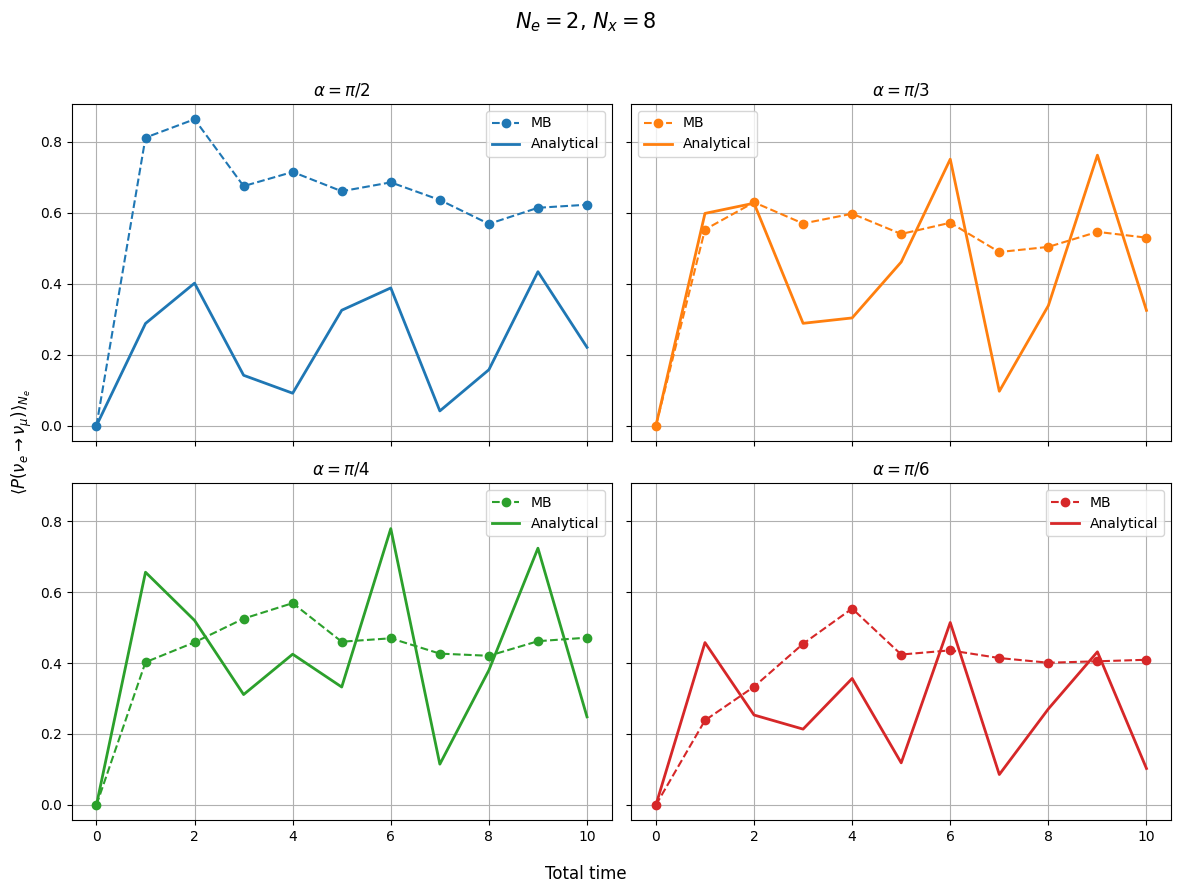

In [13]:
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]
P_mb = {}
P_emu = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (alpha, alpha_label), color in zip(axes, alpha_cases, colors):

    result = run_and_plot_alpha(
        alpha,
        alpha_label,
        show_plot=False,
    )
    t = np.linspace(0, 200, 20)

    P = collective_oscillation_probability(
        N1=Ne,
        N2=Nx,
        alpha=alpha,
        t=times,
        lam=J
    )
    P_mb[alpha_label] = result["many_body"]["P_e_to_mu_avg"]
    P_emu[alpha_label] = P
   # print(id(P_mb_1_))
    x, xlabel = get_plot_time()

    ax.plot(x, P_mb[alpha_label], "--o", color=color, label="MB")
    ax.plot(x, P_emu[alpha_label], "-", lw=2, color=color, label="Analytical")

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True)
    ax.legend()

fig.supxlabel(xlabel)
fig.supylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")
fig.suptitle(rf"$N_e={Ne}$, $N_x={Nx}$", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 